In [26]:
import matplotlib.pyplot as plt
import numpy as np
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../")

import pyanalib.pandas_helpers as ph
import warnings
from pyanalib.split_df_helpers import *
from makedf.util import *
from analysis_village.gump.gump_cuts import *
plt.style.use('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/dune.mplstyle')

In [2]:
def plot_2d_hist_from_file(filename, plot_title):
    x_edges = []
    y_edges = []
    data_rows = []

    with open(filename, 'r') as f:
        lines = f.readlines()
        x_edges = [float(x) for x in lines[0].strip('# ').split(',') if x.strip()]
        y_edges = [float(y) for y in lines[1].strip('# ').split(',') if y.strip()]
        
        for line in lines[2:]:
            if line.strip():
                row = [float(val) for val in line.strip().split(',') if val.strip()]
                data_rows.append(row)

    z_values = np.array(data_rows)

    plt.figure(figsize=(10, 6))
    X, Y = np.meshgrid(x_edges, y_edges)
    mesh = plt.pcolormesh(x_edges, y_edges, z_values.T, linewidth=0.1)
    
    plt.colorbar(mesh, label='Value')
    plt.title(plot_title)
    plt.xlabel(r'z')
    plt.ylabel(r'y')
    
    #mesh.get_cmap().set_bad(color='gray')

def bin_centers(b):
    return 0.5 * (b[:-1] + b[1:])

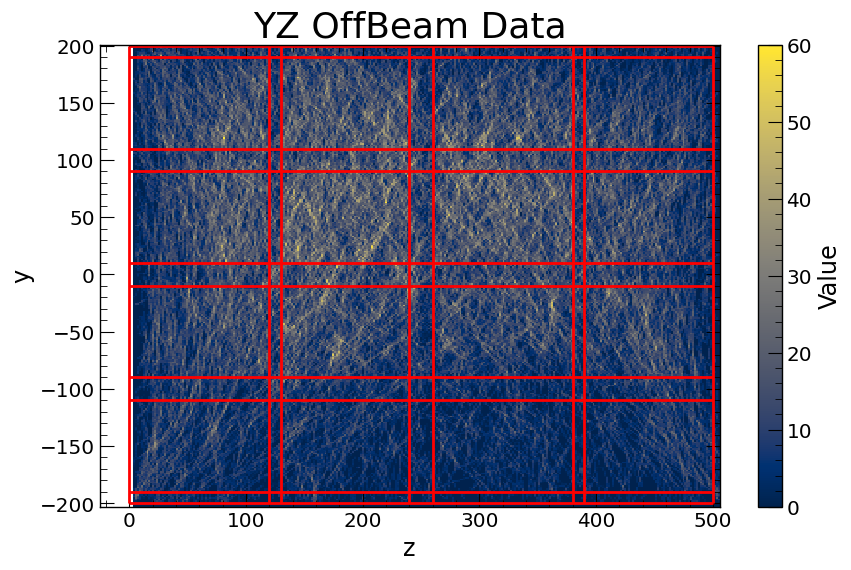

In [3]:
plot_2d_hist_from_file('/exp/sbnd/app/users/nrowe/cafpyana/analysis_village/gump/sbnd_invest/map/zy_distribution.png.txt', 'YZ OffBeam Data')
plt.vlines([0.0, 120., 130., 240., 260., 380., 390., 500.], -200, 200, color='red')
plt.hlines([-200., -190., -110., -90., -10., 10., 90., 110., 190., 200.], 0., 500, color='red')

In [40]:
prefix = "/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-6/"
dfs = []

for i in range(20):
    dfs.append(old_cuts(load_dfs(f"/exp/sbnd/data/users/gputnam/GUMP/sbn-rewgted-6/SBND_SpringMC_rewgt_5_{i}.df", ['evt'])['evt'], "SBND"))
recodf = pd.concat(dfs)


data_df = load_dfs(prefix+"SBND_SpringBNBData_Dev.df", ['evt'])['evt']
data_df = old_cuts(data_df, "SBND")

extravarnames = [
    "mu_costh",
    "mu_phi",
    "p_costh",
    "p_phi",
]

extravars = [
    lambda d: np.cos(d.mu_dir_z),
    lambda d: np.arctan2(d.mu_dir_x, d.mu_dir_y)*180/np.pi,
    lambda d: np.cos(d.p_dir_z),
    lambda d: np.arctan2(d.p_dir_x, d.p_dir_y)*180/np.pi,
]

for v, vname in zip(extravars, extravarnames):
    data_df[vname] = v(data_df)
    recodf[vname] = v(recodf)

Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts
Using old_cuts


In [5]:
def add_cathode_intercept(df, start_cols, end_cols, plane_x, cells_list):
    # 1. Extract coordinates as NumPy arrays
    p1 = df[start_cols].values
    p2 = df[end_cols].values
    
    x1, x2 = p1[:, 0], p2[:, 0]
    
    # 2. Calculate the 't' parameter where the line hits plane_z
    # Formula: t = (target_z - z1) / (z2 - z1)
    # We use np.errstate to ignore division by zero for lines parallel to the plane
    with np.errstate(divide='ignore', invalid='ignore'):
        t = (plane_x - x1) / (x2 - x1)

    # 3. Calculate intersection coordinates (y, z)
    intersect_y = p1[:, 1] + t * (p2[:, 1] - p1[:, 1])
    intersect_z = p1[:, 2] + t * (p2[:, 2] - p1[:, 2])
    
    # 4. Filter for valid intersections (0 <= t <= 1)
    # If t is outside this range, the segment doesn't reach the plane
    valid_intersection = (t >= 0) & (t <= 1)

    # 5. Initialize the result column
    df['yz_cid'] = None
    df['is_blocked'] = False
    df['y_intercept'] = None
    df['z_intercept'] = None
    # 6. Check each of the 20 cells (Looping 20 times is very fast)
    for cell in cells_list:
        cid = cell['id']
        blocked_bool = cell['is_blocked']
        ymin, zmin, ymax, zmax = cell['bounds']
        # Mask: Point is valid AND inside the bounding box
        mask = (
            valid_intersection & 
            (intersect_y >= ymin) & (intersect_y <= ymax) &
            (intersect_z >= zmin) & (intersect_z <= zmax)
        )
        df.loc[mask, 'is_blocked'] = blocked_bool
        df.loc[mask, 'yz_cid'] = cid
        df.loc[mask, 'y_intercept'] = intersect_y[mask]
        df.loc[mask, 'z_intercept'] = intersect_z[mask]

    return df

def generate_cells_from_edges(z_edges, y_edges, manual_block=None):
    """
    Generates a list of cell dictionaries based on boundary coordinates.
    
    x_edges: List of floats, e.g., [0, 5, 10, 25]
    y_edges: List of floats, e.g., [0, 2, 8]
    """
    # Sort edges to ensure intervals are calculated correctly
    z_edges = sorted(z_edges)
    y_edges = sorted(y_edges)

    
    cells = []
    cell_count = 1
    
    # Iterate through X intervals
    for i in range(len(z_edges) - 1):
        zmin = z_edges[i]
        zmax = z_edges[i+1]
        
        # Iterate through Y intervals
        for j in range(len(y_edges) - 1):
            ymin = y_edges[j]
            ymax = y_edges[j+1]
            if manual_block:
                blocked_bool = (cell_count in manual_block)
            else:
                blocked_bool = (i%2 == 1) | (j%2 == 0) # This is for catching beam cells
            # Create a unique ID and store the bounds
            cells.append({
                'id': cell_count,
                'bounds': (ymin, zmin, ymax, zmax),
                'is_blocked': blocked_bool
            })
            cell_count += 1
            
    return cells

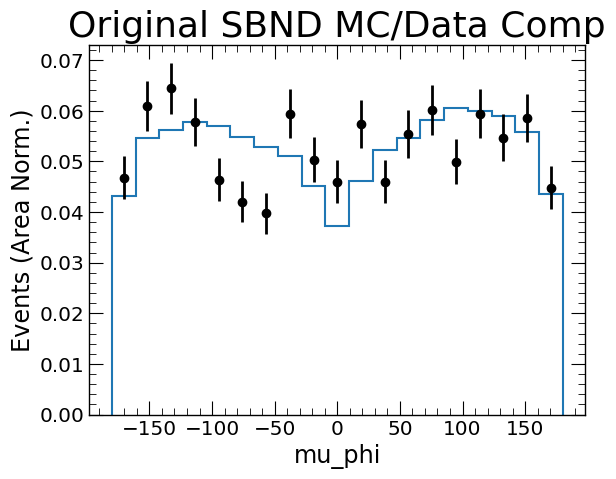

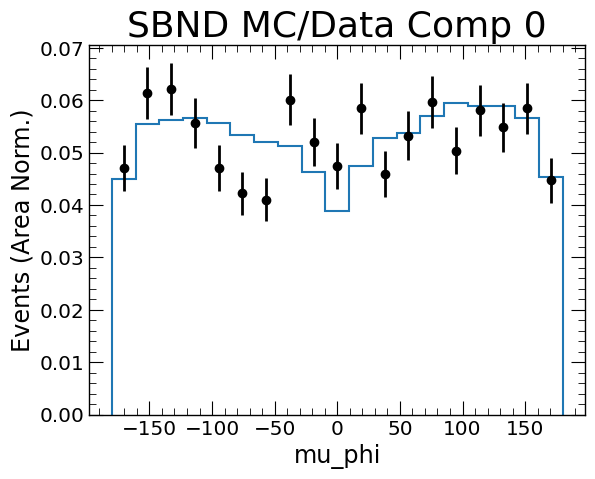

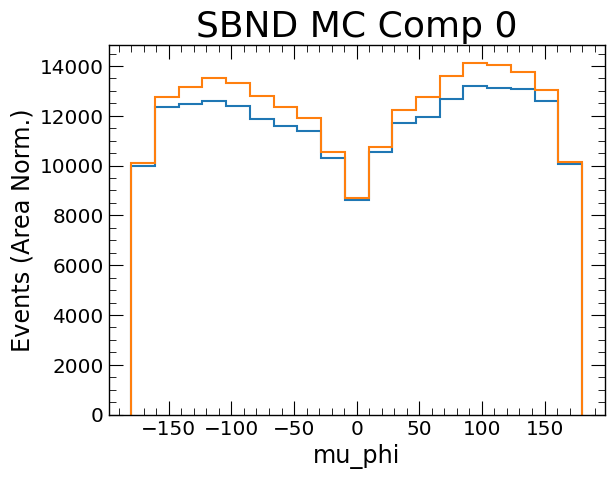

<Figure size 640x480 with 0 Axes>

In [41]:
col_1 = np.array([1, 8, 15, 22, 29, 36, 43, 50, 57])
col_2 = col_1 + np.ones_like(col_1)
col_3 = col_2 + np.ones_like(col_1)
col_4 = col_3 + np.ones_like(col_1)
col_5 = col_4 + np.ones_like(col_1)
col_6 = col_5 + np.ones_like(col_1)
col_7 = col_6 + np.ones_like(col_1)
to_block = np.concat([col_1, col_2, col_3, col_4, col_5, col_6, col_7])

row_1 = np.array([1, 2, 3, 4, 5, 6, 7])
row_2 = row_1 + 7*np.ones_like(row_1)
row_3 = row_2 + 7*np.ones_like(row_1)
row_4 = row_3 + 7*np.ones_like(row_1)
row_5 = row_4 + 7*np.ones_like(row_1)
row_6 = row_5 + 7*np.ones_like(row_1)
row_7 = row_6 + 7*np.ones_like(row_1)
row_8 = row_7 + 7*np.ones_like(row_1)
row_9 = row_8 + 7*np.ones_like(row_1)
all_rows = [row_1]#, row_2, row_3, row_4, row_5, row_6, row_7, row_8, row_9]
to_block = np.concat([row_1, row_2, row_3, row_4, row_5, row_6, row_7, row_8, row_9])

    
var = 'mu_phi'
b = np.linspace(min(recodf[var]), max(recodf[var]), 20)
plt.hist(recodf[var], bins=b, weights=np.ones_like(recodf[var])/len(recodf), histtype='step', label='mc')
n, _ = np.histogram(data_df[var], bins=b, weights=np.ones_like(data_df[var])/len(data_df))
plt.plot(bin_centers(b), n, marker='o', linestyle='none', color='black', label='data abs norm')
plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df))/len(data_df), color='black', linestyle='none')
plt.title(f'Original SBND MC/Data Comp')
plt.ylabel("Events (Area Norm.)")
plt.xlabel(var)
plt.show()
plt.clf()

#to_block=range(1,64)
for rowi, row in enumerate(all_rows):
    to_block = row
    my_yz_cells = generate_cells_from_edges([0.0, 120., 130., 240., 260., 380., 390., 500.], [-200., -190., -110., -90., -10., 10., 90., 110., 190., 200.], manual_block=list(to_block))
    
    new_recodf = add_cathode_intercept(recodf.copy(), ['slc_vtx_x', 'slc_vtx_y', 'slc_vtx_z'], ['mu_end_x', 'mu_end_y', 'mu_end_z'], plane_x=0, cells_list=my_yz_cells)
    new_data_df = add_cathode_intercept(data_df.copy(), ['slc_vtx_x', 'slc_vtx_y', 'slc_vtx_z'], ['mu_end_x', 'mu_end_y', 'mu_end_z'], plane_x=0, cells_list=my_yz_cells)
    
    new_recodf = new_recodf[(new_recodf.is_blocked == False)]
    new_data_df = new_data_df[(new_data_df.is_blocked == False)]
    
    var = 'mu_phi'
    b = np.linspace(min(new_recodf[var]), max(new_recodf[var]), 20)
    plt.hist(new_recodf[var], bins=b, weights=np.ones_like(new_recodf[var])/len(new_recodf), histtype='step', label='mc')
    n, _ = np.histogram(new_data_df[var], bins=b, weights=np.ones_like(new_data_df[var])/len(new_data_df))
    plt.plot(bin_centers(b), n, marker='o', linestyle='none', color='black', label='data abs norm')
    plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(new_data_df))/len(new_data_df), color='black', linestyle='none')
    plt.title(f'SBND MC/Data Comp {rowi}')
    plt.ylabel("Events (Area Norm.)")
    plt.xlabel(var)
    plt.show()
    plt.clf()
    
    b = np.linspace(min(new_recodf[var]), max(new_recodf[var]), 20)
    plt.hist(new_recodf[var], bins=b, histtype='step', label='mc new')
    plt.hist(recodf[var], bins=b, histtype='step', label='mc old')
    plt.title(f'SBND MC Comp {rowi}')
    plt.ylabel("Events (Area Norm.)")
    plt.xlabel(var)
    plt.show()
    plt.clf()

In [161]:
new_recodf = new_recodf[(new_recodf.is_blocked == False)]
new_data_df = new_data_df[(new_data_df.is_blocked == False)]

def crossing_cut(df):
    return (np.sign(df.slc_vtx_x) == np.sign(df.mu_end_x)) & (np.sign(df.slc_vtx_x) == np.sign(df.p_end_x))

#new_recodf = recodf[crossing_cut(recodf.copy())]
#new_data_df = data_df[crossing_cut(data_df.copy())]
#plot_arrows(new_recodf, n=20, mask_bool=True)

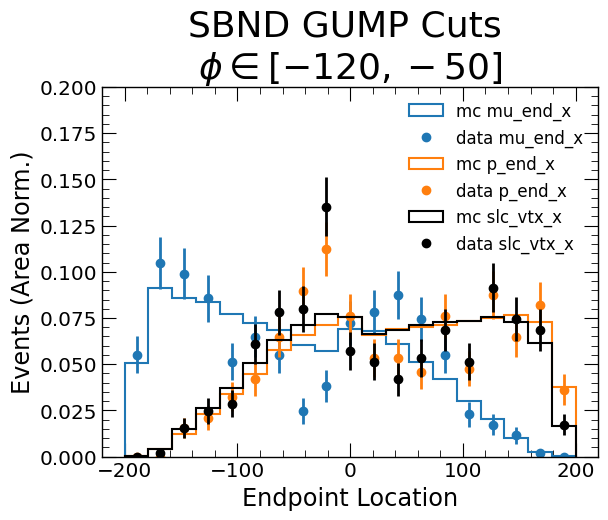

<Figure size 640x480 with 0 Axes>

In [162]:
#recodf_new = recodf[(recodf.mu_phi < -50.) & (recodf.mu_phi > -120.)]
#data_df_new = data_df[(data_df.mu_phi < -50.) & (data_df.mu_phi > -120.)]
recodf_new = new_recodf
data_df_new = new_data_df

#recodf_new = recodf
#data_df_new = data_df

recodf_new = recodf_new[(recodf_new.mu_phi < -50.) & (recodf_new.mu_phi > -120.)]
data_df_new = data_df_new[(data_df_new.mu_phi < -50.) & (data_df_new.mu_phi > -120.)]

b = np.linspace(-200., 200., 20)
for var, c in zip(['mu_end_x', 'p_end_x', 'slc_vtx_x'], ['tab:blue', 'tab:orange', 'black']):
    plt.hist(recodf_new[var], bins=b, weights=np.ones_like(recodf_new[var])/len(recodf_new), color=c, histtype='step', label=f'mc {var}')
    n, _ = np.histogram(data_df_new[var], bins=b, weights=np.ones_like(data_df_new[var])/len(data_df_new))
    plt.plot(bin_centers(b), n, marker='o', linestyle='none', color=c, label=f'data {var}')
    plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df_new))/len(data_df_new), color=c, linestyle='none')
plt.title(f'SBND GUMP Cuts \n$\phi \in [-120, -50]$')
plt.legend()
plt.ylim(0., 0.2)
plt.ylabel("Events (Area Norm.)")
plt.xlabel('Endpoint Location')
plt.show()
plt.clf()

In [135]:
def plot_arrows(df, n=None, mask_bool=True, title_str=''):
    """
    Plots muon trajectories as arrows to show direction.
    """
    # Filter for phi range and limit to 100
    if n:
        df = df.head(n)
    mask = (df['mu_phi'] > -120) & (df['mu_phi'] < -50)

    if mask_bool:
        df_sub = df[mask]
    else:
        df_sub = df

    if len(df_sub) > 0:
        plt.figure(figsize=(10, 8))
        
        # Calculate displacement vectors
        mu_dx = df_sub['mu_end_x'] - df_sub['slc_vtx_x']
        mu_dy = df_sub['mu_end_y'] - df_sub['slc_vtx_y']
        
        p_dx = df_sub['p_end_x'] - df_sub['slc_vtx_x']
        p_dy = df_sub['p_end_y'] - df_sub['slc_vtx_y']
        
        # quiver(x_start, y_start, dx, dy)
        # angles='xy', scale_units='xy', scale=1 ensures the arrows 
        # point exactly to the end coordinates.
        mu_q = plt.quiver(df_sub['slc_vtx_x'], df_sub['slc_vtx_y'], mu_dx, mu_dy, 
                       color='blue', alpha=0.6, 
                       angles='xy', scale_units='xy', scale=1,
                       width=0.003, headwidth=5, headlength=7, label='Muons')
    
        p_q = plt.quiver(df_sub['slc_vtx_x'], df_sub['slc_vtx_y'], p_dx, p_dy, 
                       color='purple', alpha=0.6, 
                       angles='xy', scale_units='xy', scale=1,
                       width=0.003, headwidth=5, headlength=7, label='Protons')
        
        # Optional: Scatter the vertex points for clarity
        plt.scatter(df_sub['slc_vtx_x'], df_sub['slc_vtx_y'], 
                    color='red', s=10, label='Vertex', zorder=3)
    
        plt.xlim(-200., 200.)
        plt.ylim(-200., 200.)
        plt.xlabel('X Position [cm]')
        plt.ylabel('Y Position [cm]')
        first_str=''
        if n:
            first_str = f"(First {n}) "
        if mask_bool:
            plt.title(f'Muon Directionality {first_str}\n$\phi \in [-120, -50]$ '+title_str)
        else:
            plt.title(f'Muon Directionality {first_str}'+title_str)
            
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

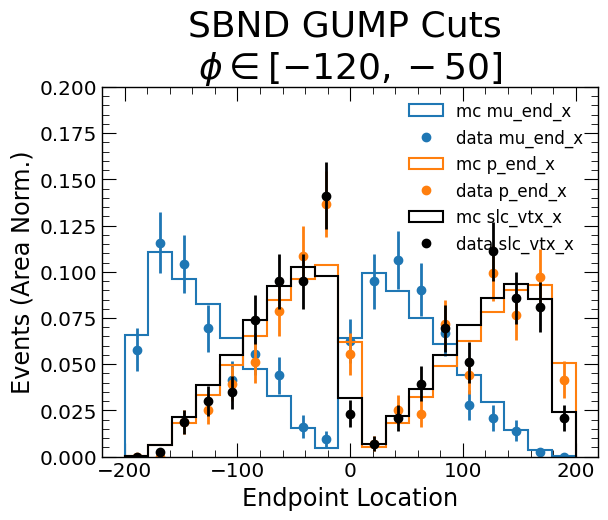

<Figure size 640x480 with 0 Axes>

In [120]:
#recodf_new = recodf[(recodf.mu_phi < -50.) & (recodf.mu_phi > -120.)]
#data_df_new = data_df[(data_df.mu_phi < -50.) & (data_df.mu_phi > -120.)]

recodf_new = new_recodf
data_df_new = new_data_df

#recodf_new = recodf
#data_df_new = data_df

recodf_new = recodf_new[(recodf_new.mu_phi < -50.) & (recodf_new.mu_phi > -120.)]
data_df_new = data_df_new[(data_df_new.mu_phi < -50.) & (data_df_new.mu_phi > -120.)]

b = np.linspace(-200., 200., 20)
for var, c in zip(['mu_end_x', 'p_end_x', 'slc_vtx_x'], ['tab:blue', 'tab:orange', 'black']):
    plt.hist(recodf_new[var], bins=b, weights=np.ones_like(recodf_new[var])/len(recodf_new), color=c, histtype='step', label=f'mc {var}')
    n, _ = np.histogram(data_df_new[var], bins=b, weights=np.ones_like(data_df_new[var])/len(data_df_new))
    plt.plot(bin_centers(b), n, marker='o', linestyle='none', color=c, label=f'data {var}')
    plt.errorbar(bin_centers(b), n, yerr=np.sqrt(n*len(data_df_new))/len(data_df_new), color=c, linestyle='none')
plt.title(f'SBND GUMP Cuts \n$\phi \in [-120, -50]$')
plt.legend()
plt.ylim(0., 0.2)
plt.ylabel("Events (Area Norm.)")
plt.xlabel('Endpoint Location')
plt.show()
plt.clf()